# 02. Pair distances and the nearest-neighbour cutoff

**Goal.** Compute the pair-distance distribution function (PDDF) and the radial distribution function (RDF) of a cluster, and derive the first-minimum cutoff R_cut that every adjacency-based quantity in Sapphire depends on.

**You need.** Tutorial 01 (we rebuild Au561 in one line).

Sapphire is a post-processing environment for metallic nanoparticle (MNP) simulations. This series
builds up from a single structure to full molecular-dynamics trajectories; every notebook runs
offline on data bundled with the package and finishes in well under a minute.


In [1]:
import numpy as np, matplotlib.pyplot as plt
from ase.cluster import Icosahedron
from Sapphire.Post_Process import DistFuncs, Kernels

au = Icosahedron("Au", noshells=6, latticeconstant=4.08)
pos = au.positions
dist = DistFuncs.Euc_Dist(pos)                 # all N(N-1)/2 pair distances
print(len(dist), "pairs; shortest %.3f Å" % min(dist))

157080 pairs; shortest 2.885 Å


## 2.1 Histogram vs kernel density estimate

A raw histogram of 157 080 distances is noisy at short range and its minima depend on the bin width.
Sapphire instead uses a **Gaussian kernel density estimate** (KDE): every distance contributes a
Gaussian of width `Band` (0.05 Å is a good default for metals), giving a smooth, differentiable
curve whose first minimum defines the nearest-neighbour shell.

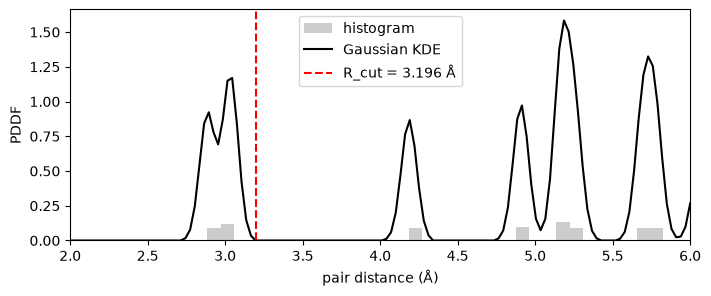

In [2]:
K = Kernels.Gauss(dist, 0.05)                  # standalone: no System -> nothing written to disk
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(dist, bins=300, density=True, color="0.8", label="histogram")
ax.plot(K.Space, K.Density, "k", label="Gaussian KDE")
ax.axvline(K.ReturnRCut(), color="r", ls="--", label="R_cut = %.3f Å" % K.ReturnRCut())
ax.set_xlim(2, 6); ax.set_xlabel("pair distance (Å)"); ax.set_ylabel("PDDF"); ax.legend(); plt.show()

The first minimum sits between the first shell (2.88 Å = a/√2) and the second (4.08 Å = a). For a
thermalised frame the peaks broaden and the minimum moves — which is why `Process` recomputes
R_cut **every frame** rather than fixing it.

## 2.2 RDF: the same information, normalised by shell volume

`DistFuncs.RDF` counts pairs in spherical shells around each atom and divides by the shell volume,
so g(r) → constant for a bulk-like interior. Its `Radii`/`G` arrays are what `Graphing` plots.

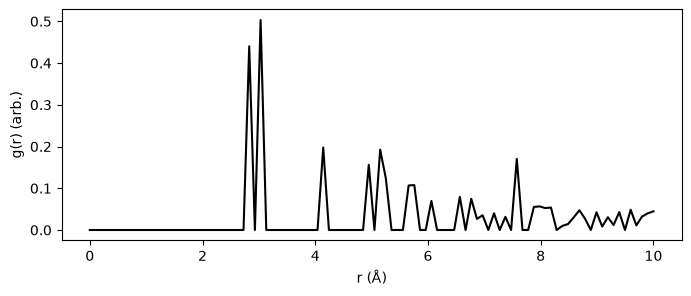

In [3]:
P = DistFuncs.RDF(System=None, Positions=pos, Res=100, R_Cut=10.0)
plt.figure(figsize=(8, 3)); plt.plot(P.Radii, P.G, "k"); plt.xlabel("r (Å)"); plt.ylabel("g(r) (arb.)"); plt.show()

## 2.3 Bandwidth matters

Too small a bandwidth resolves noise, too large merges shells. Sweep it and watch R_cut.

In [4]:
for band in (0.02, 0.05, 0.1, 0.2, 0.4):
    print("Band = %.2f Å  ->  R_cut = %.3f Å" % (band, Kernels.Gauss(dist, band).ReturnRCut()))

Band = 0.02 Å  ->  R_cut = 3.106 Å
Band = 0.05 Å  ->  R_cut = 3.196 Å


Band = 0.10 Å  ->  R_cut = 3.347 Å
Band = 0.20 Å  ->  R_cut = 3.588 Å


Band = 0.40 Å  ->  R_cut = 3.769 Å


## 2.4 Other kernels

`Kernels.Uniform` and `Kernels.Epan` (Epanechnikov) are available with the same interface; Gaussian is
recommended because the derivative used to locate the minimum is smooth.

## 2.5 Try it

* `au.rattle(0.2, seed=1)` then repeat 2.1 — how far does R_cut move?
* For a bimetallic cluster the *homo* PDDFs differ (Pt–Pt < Au–Au); `Process` computes a
  cutoff per species (`hocutAu`, `hocutPt`). We will see them in Tutorial 05.

**Next:** *03 — Adjacency, coordination and the aGCN catalysis model.*